# Moving Averages

First, to see what the total return on investment would be if we had put a lump sum in at the start of the period, 2016-2020, we can see how profitable the different strategies are based on the buy-and-hold benchmark. Then, we can look at different indicators to create even more in-depth price signals using the Python library `TA-Lib`.

Such indicators would be:

* Simple-Moving Averages (SMA)
* Exponential Weighted Averages (EWMA)
* RSI - overbought if RSI is above 70 and oversold when under 30
* MACD - shows relationship between two moving averages of a security's price. MACD = 26-day EMA - 12-day EMA
* Bollinger Bands - Plotted two std. from a simple moving average. Help to identify whether an asset is overbought/oversold
* ROC

The most used technical indicators are the 200 and 50-day moving averages and EMA. Which we will explore below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from utils.read_prices import read_parquet
from utils.metrics import Metrics as m
import talib

In [2]:
df = read_parquet()
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


In [3]:
backtest_df = read_parquet("../price_ranges/btc_price_2021-2025.parquet")
backtest_df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.09,NaN,NaN
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.09,1.093726,0.089590
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,0.09,1.020380,0.020175
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.09,0.975288,-0.025022
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.09,1.063197,0.061280


In [4]:
#Using the cumulative returns we can simulate an investment of $1,000 at the beginning of 2016 and run it through to the end of 2020 to see our total return over that time-frame.

init_investment = 1000.0

terminal_return = (np.exp(df['log_returns'].cumsum()) - 1) * init_investment

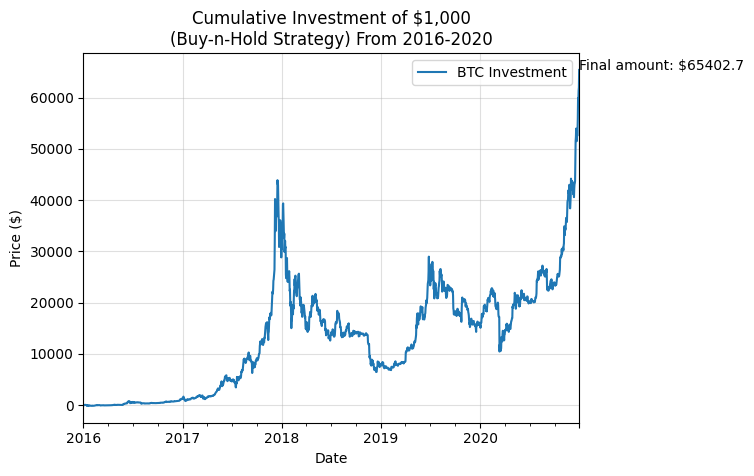

In [5]:
terminal_return.plot(kind='line', label="BTC Investment")
plt.ylabel('Price ($)')
plt.legend()
plt.title('Cumulative Investment of $1,000\n(Buy-n-Hold Strategy) From 2016-2020')

final_amount = round(terminal_return.tolist()[-1], 2)

plt.annotate(text=f"Final amount: ${final_amount}",
            xy=(terminal_return.index.tolist()[-1],
            terminal_return.tolist()[-1]))
plt.grid(alpha=.4)
plt.show()

If we had put in $1,000 at the beginning of the year 2016, by the end of 2020, that $1,000 would total over $65,000.

Below, we will see that the terminal rate is the multiple that the price has increased/decreased by.

## Metrics

Before we look at different moving average strategies, we'll look at different metrics that can be calculated to measure the success of a strategy using Peng Liu's book *Quantitative Trading Strategies Using Python: Technical Analysis, Statistical Testing, and Machine Learning* as a guide.

Another strategy called pairs trading is outlined in the book, but as of now with this project, we will forego that strategy and look at the previous two mentioned.

### Terminal Return

This approach ignores intermediate returns and only considers the initial and terminal asset prices; a simplified view of the asset price's growth.

With the graph above, the terminal rate would essentially be a buy-and-hold strategy where the terminal rate would be the multiple that you would multiply the initial investment by to obtain the final investment amount.

In [6]:
df["Close"].iloc[-1]/df["Close"].iloc[0] - 1

np.float64(65.40270422323037)

In [7]:
init_investment * 65.4027

65402.7

In [8]:
terminal_return = round((final_amount / init_investment) - 1, 2)*100

print(f"Terminal return of an initial investment of $1,000: {terminal_return:.2f}%")
print(f"Terminal return of bitcoin during the same time-frame: {m.terminal_return(df['log_returns'])*100:.2f}%")

Terminal return of an initial investment of $1,000: 6440.00%
Terminal return of bitcoin during the same time-frame: 6540.27%


In [9]:
## checking to see that the terminal return as a mulitple checks out from the terminal value of the close price

(df['Close'].tolist()[0] * (1 + m.terminal_return(df['log_returns']))), df['Close'].tolist()[-1]

(28840.953124999876, 28840.953125)

In [10]:
'''
Annualizing Returns:

Some returns are monthly, quarterly, or yearly. This metric compares different assets that might have different return time-scales.
'''

daily_returns = df['returns'].prod() ** (1 / df['returns'].shape[0]) - 1

'''
Let us decompose the sequence of operations here. First, we construct the 1+R returns for each day, then perform sequential compounding using the prod() function to obtain the cumulative terminal return in 1+R format. Before subtracting one, we raise it to the power of 1/N, where N is the number of rows in the DataFrame. This gives the geometric mean of the returns in 1+R format. We do not use the arithmetic mean here.
'''

annualized_returns_long_way = ((1 + daily_returns) ** 365) - 1

'''
We assume a fixed daily return as the geometric mean and roll it forward by a year, corresponding to 365 trading days. Again, convert between 1+R return and the normal return.
'''

## same calculation but in ont line
annualized_returns_short_way = df['returns'].prod()**(365 / df['returns'].shape[0]) - 1

print(f"Annualized return sanity check 1: {annualized_returns_long_way}")
print(f"Annualized return sanity check 2: {annualized_returns_short_way}")
print(f"Annualized return sanity check 3: {m.annualized_return(df['returns'])}")

Annualized return sanity check 1: 1.3133298991034934
Annualized return sanity check 2: 1.3133298991034779
Annualized return sanity check 3: 1.3133298991034779


In [11]:
'''
Volatility and Risk:

The standard deviation (measure of volatility) of the returns measures "how large the prices swing around the mean price and serves as a direct measure of the dispersion of returns." This metric plays an important role in assessing the risk tolerance in a portfolio.

Volatility can be daily, monthly, yearly, etc. Our case it is daily.

The higher the volatility, the higher the risk.
'''

price_stats = df.describe()
price_stats

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
count,1826.000000,1826.000000,1826.000000,1826.000000,1.826000e+03,1826.000000,1825.000000,1825.000000
mean,6118.848393,6259.301537,5945.559781,6103.383477,1.164336e+10,1.151857,1.003077,0.002299
std,4703.295017,4820.207635,4535.488914,4674.882347,1.376704e+10,0.807101,0.039170,0.039534
min,364.330994,374.950012,354.914001,365.072998,2.851400e+07,0.040000,0.628305,-0.464730
25%,1187.825043,1206.202515,1172.047485,1184.262512,3.338000e+08,0.380000,0.988796,-0.011267
50%,6413.792480,6534.830078,6314.354980,6412.694824,5.302091e+09,1.160000,1.002180,0.002178
75%,9208.396973,9360.110352,9035.487061,9209.826904,1.898423e+10,1.907500,1.017551,0.017399
max,28840.953125,28937.740234,27360.089844,27360.089844,7.415677e+10,2.450000,1.252472,0.225119


In [12]:
## price volatility

price_volatility = price_stats['returns'].loc['std']
print(price_volatility)
print(m.volatility(df['returns']))

0.039169565899702836
0.039169565899702836


In [13]:
'''
Annulaize Volatility:

Like the annualization of returns makes it easier for us to compare two assets with different time-frames, so to does annulaizing the volatility.

square root(T) * single period volatility 
     |                   |
  T = 365 since      our case this is daily
  our time-frame
    is daily

'''

annualized_volatility = np.sqrt(365) * price_volatility

print(annualized_volatility)
print(m.annualized_volatility(T=365, single_period_volatility=m.volatility(df['returns'])))

0.7483335057723091
0.7483335057723091


In [14]:
'''
Sharpe Ratio:

Divide the excess return by volatility to assess risk-adjusted performance.

Risk-free rate is typically the Treasury bill or bond.

Higher -> investment yields higher returns for the same level of risk compared to other investments or the overall market.

More accurate assessment of investment's performance relative to overall market conditions.

sharpe_ratio = average_return - risk_free_rate / annualized_volatility
'''

risk_free_rate = .03

excess_return = annualized_returns_short_way - risk_free_rate

sharpe_ratio = excess_return / annualized_volatility

print(sharpe_ratio)
print(m.sharpe_ratio(
    annualized_returns=m.annualized_return(df['returns']),
    annualized_volatility=m.annualized_volatility(
        T=365,
        single_period_volatility=m.volatility(df['returns'])
    ),
    risk_free_rate=risk_free_rate))

1.7149170646569298
1.7149170646569298


## Trend-Following Strategies

Moving averages can also help identify support and resistance levels. Support level is a price/range where the price has had trouble falling below over a certain period, whereas the resistance level is one where the price has had trouble breaking past.

When short-term moving average crosses above the long-term moving average, it signals a buy action (enter long position).

When the oposite happens it signals a sell action (enter short position).

**If only one trend line**, the strategy works the same. If the price is greater than the moving average this signals a buy action, and vice versa.

In [15]:
df = df[['Close', 'Volume', 'returns', 'log_returns', 'interest_rate']].copy().dropna()  ## copy for moving averages
df.head()

,Close,Volume,returns,log_returns,interest_rate
Date,,,,,
2016-01-02,433.437988,30096600,0.997937,-0.002065,0.20
2016-01-03,430.010986,39633800,0.992093,-0.007938,0.20
2016-01-04,433.091003,38477500,1.007163,0.007137,0.36
2016-01-05,431.959991,34522600,0.997389,-0.002615,0.36
2016-01-06,429.105011,34042500,0.993391,-0.006631,0.36


In [16]:
window = 50

SMA1 = 'SMA-'+str(window)

df[SMA1] = df['Close'].rolling(window, min_periods=1).mean()

## longer period SMA

window = 200

SMA2 = 'SMA-'+str(window)

df[SMA2] = df['Close'].rolling(window, min_periods=1).mean()

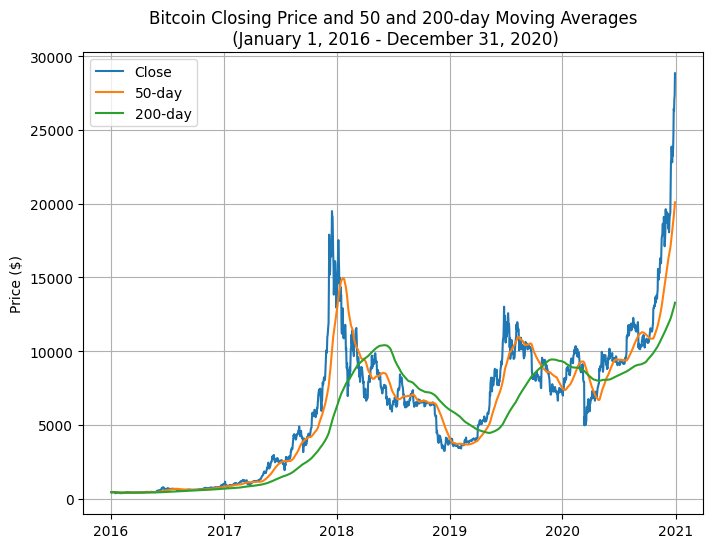

In [17]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(df[['Close', 'SMA-50', 'SMA-200']], label=['Close', '50-day', '200-day'])
ax.set_title('Bitcoin Closing Price and 50 and 200-day Moving Averages\n (January 1, 2016 - December 31, 2020)')
ax.set_ylabel('Price ($)')
ax.legend()
plt.grid(.4)
plt.show()

In [18]:
## buy signal
df['signal'] = np.where(df['SMA-50'] > df['SMA-200'], 1, 0)

## sell signal
df['signal'] = np.where(df['SMA-50'] < df['SMA-200'], -1, df['signal'])

In [19]:
df['signal'].value_counts()

signal
 1    1182
-1     593
 0      50
Name: count, dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df['signal'].value_counts(), df['signal'].value_counts(normalize=True)

(signal
  1    1182
 -1     593
  0      50
 Name: count, dtype: int64,
 signal
  1    0.647671
 -1    0.324932
  0    0.027397
 Name: proportion, dtype: float64)

Multiplying the 'signal' column with the 'log_returns' column we obtain the single-period log return for the trend following strategy.

In [22]:
df['log_return_trend_follow'] = df['signal'] * df['log_returns']

Compared with the buy-and-hold strategy, the key difference is the additional shorting actions generated by the trend-following strategy. That is, when the stock price drops, the buy-and-hold strategy will register a loss, while the trend-following strategy will make a profit if the trading signal is to go short. Creating a good trading signal thus makes all the difference.

Next, we create explicit trading actions. The signal column tells us whether we should go long or short in the given asset under the trend-following strategy. However, this does not mean we need to make a trade at every period. If the signal remains the same for two consecutive periods, we simply hold on to the position and remain seated. In other words, there is no trading action for this specific trading day. This applies in the case of two consecutive 1s or –1s in the signal column.

In [23]:
df['action'] = df['signal'].diff()

In [24]:
df['action'].value_counts()

action
 0.0    1816
 2.0       4
-2.0       3
-1.0       1
Name: count, dtype: int64

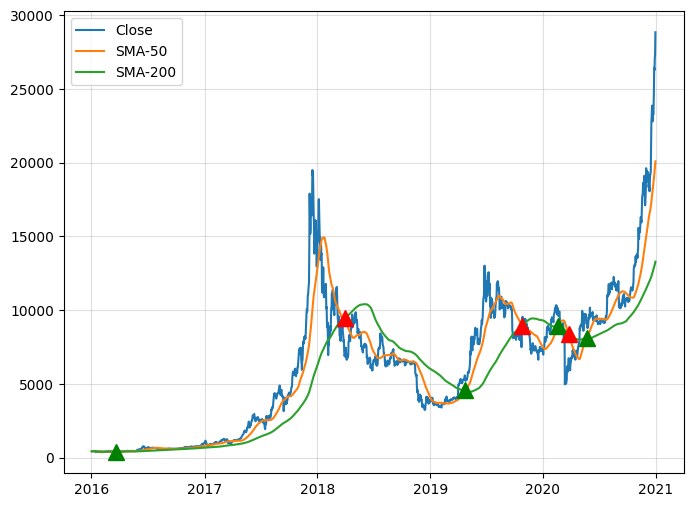

In [25]:
plt.figure(figsize=(8,6))

plt.plot(df['Close'], label='Close')
plt.plot(df['SMA-50'], label='SMA-50')
plt.plot(df['SMA-200'], label='SMA-200')
# plt.plot(np.exp(df["log_return_trend_follow"].cumsum())*init_investment)
plt.plot(
    df.loc[df.action == 2].index,
    df['SMA-50'][df.action == 2],
    '^',
    color = 'g',
    markersize = 12)
plt.plot(
    df.loc[df.action == -2].index,
    df['SMA-200'][df.action == -2],
    '^',
    color = 'r',
    markersize = 12)

plt.grid(alpha=.4)
plt.legend()
plt.show()

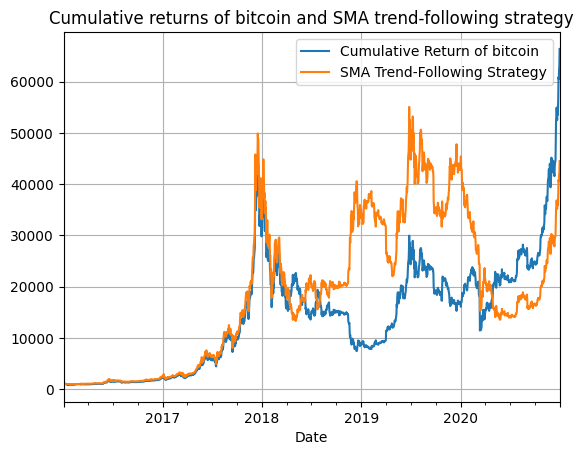

In [26]:
cum_returns = np.exp(df[['log_returns', 'log_return_trend_follow']].cumsum())*init_investment
cum_returns.plot(kind="line")
plt.legend(['Cumulative Return of bitcoin', 'SMA Trend-Following Strategy'])
plt.title("Cumulative returns of bitcoin and SMA trend-following strategy")
plt.grid(.4)
plt.show()

In [27]:
# fig, ax = plt.subplots(2, 1, figsize=(12, 6))

# ax[0].plot(np.exp(df[['log_returns', 'log_return_trend_follow']].cumsum()),
#            label=['Cumlative Return', 'Trend-Following Strategy'])
# ax[0].set_title('Cumulative return of trading strategy and bitcoin')
# ax[0].set_ylabel('Terminal Return (as the multiplier)')
# ax[0].grid(.4)
# ax[0].legend()

# ax[1].plot(df['interest_rate'], label='Interest Rate')
# ax[1].set_ylabel('Interest Rate (%)')
# ax[1].legend()
# ax[1].grid(.4)

# plt.show()

In [28]:
## terminal returns buy-n-hold
terminal_return_buy_n_hold = m.terminal_return(df['log_returns']) * 100

## terminal return trend-follow
terminal_return_trend_follow = m.terminal_return(df['log_return_trend_follow']) * 100

## annualized returns
ann_returns_buy_n_hold = m.annualized_return(df["returns"]) * 100
ann_returns_trend_follow = m.annualized_return(np.exp(df["log_return_trend_follow"])) * 100

print(f"Terminal return of buy-n-hold strategy from July 2016 to Decmeber 2020: {terminal_return_buy_n_hold:.2f}%")
print(f"Terminal return of trend-follow strategy from July 2016 to Decmeber 2020: {terminal_return_trend_follow:.2f}%\n")
print(f"Annualized returns of asset: {ann_returns_buy_n_hold}%")
print(f"Annualized returns of trend-strategy: {ann_returns_trend_follow}%\n")

## ann. vol. buy-n-hold
annualized_volatility_bnh = m.annualized_volatility(365, m.volatility(df["log_returns"]))

## ann. vol. trend follow
annualized_volatility_trend_follow = m.annualized_volatility(365, m.volatility(df["log_return_trend_follow"]))

print(f"Annualized volatility buy-n-hold: {annualized_volatility_bnh}")
print(f"Annualized volatility trend-follow:{annualized_volatility_trend_follow}")

Terminal return of buy-n-hold strategy from July 2016 to Decmeber 2020: 6540.27%
Terminal return of trend-follow strategy from July 2016 to Decmeber 2020: 4351.54%

Annualized returns of asset: 131.43932458998623%
Annualized returns of trend-strategy: 113.6495765966242%

Annualized volatility buy-n-hold: 0.7552960313996524
Annualized volatility trend-follow:0.7466208122919787


In [29]:
trend_follow_sharpe = m.sharpe_ratio(
    annualized_returns=m.annualized_return(df["returns"]),
    annualized_volatility=m.annualized_volatility(T=365, single_period_volatility=m.volatility(df["log_return_trend_follow"])),
    risk_free_rate=.03)

print(f"Bitcoin sharpe ratio: {sharpe_ratio}")
print(f"Trend following sharpe ratio: {trend_follow_sharpe}")

Bitcoin sharpe ratio: 1.7149170646569298
Trend following sharpe ratio: 1.7202751714850113


Looking at the terminal returns we can see that the buy-n-hold strategy gives a slight better return, but like I mentioned before, the price swing from the beggining of this period to the end saw bitcoin go from around the $20,000 mark to over $100,000, indicating that the strategies might not be indicitive of other periods where the price is on a different trajectory.

## EMA

EMA's tend to react quicker to more recent price changes than SMA's, making them more preferable to short-term traders/more volatile markets. This could be good for bitcoin?

In [30]:
alpha = .1 ## higher degree of smoothing

EWM_1 = 'EWM_'+str(alpha)

df[EWM_1] = df["Close"].ewm(alpha=alpha, adjust=False).mean()
backtest_df[EWM_1] = backtest_df['Close'].ewm(alpha=alpha, adjust=False).mean()

In [31]:
alpha = .5 ## more susceptible to recent price changes

EWM_2 = 'EWM_'+str(alpha)

df[EWM_2] = df['Close'].ewm(alpha=alpha, adjust=False).mean()
backtest_df[EWM_2] = backtest_df['Close'].ewm(alpha=alpha, adjust=False).mean()

df.head()

,Close,Volume,returns,log_returns,interest_rate,SMA-50,SMA-200,signal,log_return_trend_follow,action,EWM_0.1,EWM_0.5
Date,,,,,,,,,,,,
2016-01-02,433.437988,30096600,0.997937,-0.002065,0.20,433.437988,433.437988,0,-0.0,NaN,433.437988,433.437988
2016-01-03,430.010986,39633800,0.992093,-0.007938,0.20,431.724487,431.724487,0,-0.0,0.0,433.095288,431.724487
2016-01-04,433.091003,38477500,1.007163,0.007137,0.36,432.179993,432.179993,0,0.0,0.0,433.094860,432.407745
2016-01-05,431.959991,34522600,0.997389,-0.002615,0.36,432.124992,432.124992,0,-0.0,0.0,432.981373,432.183868
2016-01-06,429.105011,34042500,0.993391,-0.006631,0.36,431.520996,431.520996,0,-0.0,0.0,432.593737,430.644440


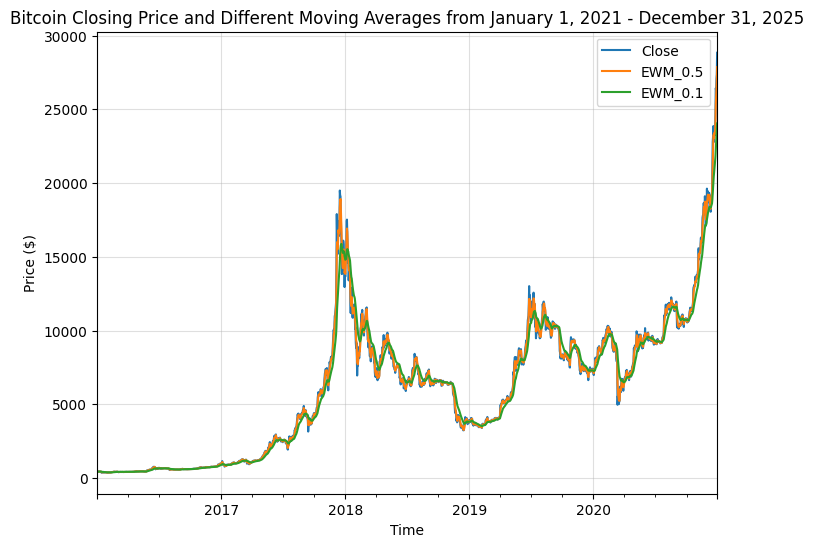

In [32]:
df[['Close', 'EWM_0.5', 'EWM_0.1']].plot(figsize=(8,6))
plt.xlabel('Time')
plt.ylabel('Price ($)')
plt.title('Bitcoin Closing Price and Different Moving Averages from January 1, 2021 - December 31, 2025')
plt.grid(alpha=.4)
plt.show()

In [33]:
## buy signal
df['ewm_signal'] = np.where(df['EWM_0.5'] > df['EWM_0.1'], 1, 0)

## sell signal
df['ewm_signal'] = np.where(df['EWM_0.5'] < df['EWM_0.1'], -1, df['ewm_signal'])

In [34]:
df['log_return_ewm_trend_follow'] = df['ewm_signal'] * df['log_returns']

In [35]:
df['ewm_action'] = df['ewm_signal'].diff()

In [36]:
df['ewm_action'].value_counts()

ewm_action
 0.0    1698
 2.0      63
-2.0      62
-1.0       1
Name: count, dtype: int64

In [37]:
df["EWM_0.5"][df.ewm_action == 2]

Date
2016-01-07      444.346222
2016-02-13      386.803489
2016-03-11      418.573541
2016-03-16      416.590474
2016-03-22      415.623176
                  ...     
2020-09-27    10736.714795
2020-09-29    10783.912097
2020-10-05    10712.594406
2020-10-08    10789.710043
2020-12-12    18531.717410
Name: EWM_0.5, Length: 63, dtype: float64

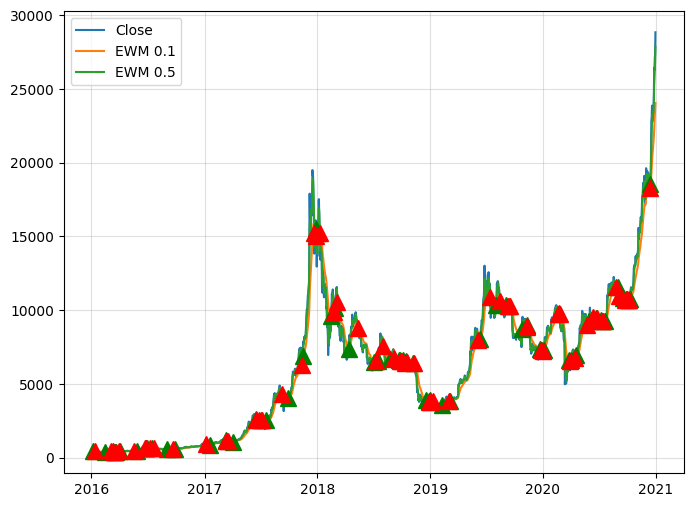

In [38]:
plt.figure(figsize=(8,6))

plt.plot(df['Close'], label='Close')
plt.plot(df['EWM_0.1'], label='EWM 0.1')
plt.plot(df['EWM_0.5'], label='EWM 0.5')
plt.plot(
    df.loc[df.ewm_action == 2].index,
    df['EWM_0.5'][df.ewm_action == 2],
    '^',
    color = 'g',
    markersize = 12)
plt.plot(
    df.loc[df.ewm_action == -2].index,
    df['EWM_0.5'][df.ewm_action == -2],
    '^',
    color = 'r',
    markersize = 12)

plt.grid(alpha=.4)
plt.legend()
plt.show()

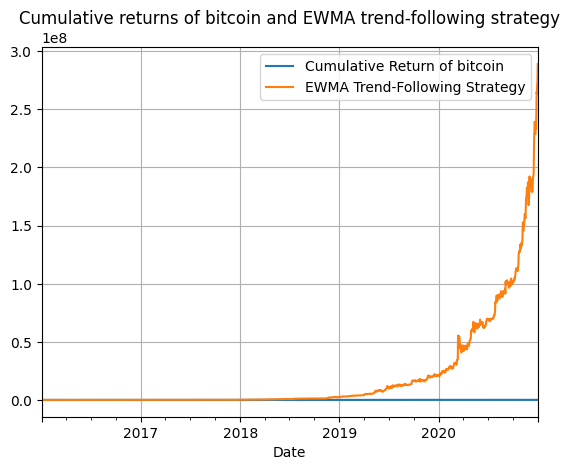

In [39]:
ewm_returns = np.exp(df[['log_returns', 'log_return_ewm_trend_follow']].cumsum())*init_investment
ewm_returns.plot(kind="line")
plt.legend(['Cumulative Return of bitcoin', 'EWMA Trend-Following Strategy'])
plt.title("Cumulative returns of bitcoin and EWMA trend-following strategy")
plt.grid(.4)
plt.show()

In [40]:
## terminal return ewm-trend-follow
terminal_return_ewm = m.terminal_return(df['log_return_ewm_trend_follow']) * 100

print(f"Terminal return of buy-n-hold strategy from July 2016 to Decmeber 2020: {terminal_return_buy_n_hold:.2f}%\n")
print(f"Terminal return of sma-trend-follow strategy from July 2016 to Decmeber 2020: {terminal_return_trend_follow:.2f}%\n")
print(f"Terminal return of ewm-trend-follow strategy from July 2016 to Decmeber 2020: {terminal_return_ewm:.2f}%\n")

## ann. vol. trend follow
annualized_volatility_ewm = m.annualized_volatility(365, m.volatility(df["log_return_ewm_trend_follow"]))

print(f"Annualized volatility buy-n-hold: {annualized_volatility_bnh}\n")
print(f"Annualized volatility sma:{annualized_volatility_trend_follow}\n")
print(f"Annualized volatility ewm:{annualized_volatility_ewm}")

Terminal return of buy-n-hold strategy from July 2016 to Decmeber 2020: 6540.27%

Terminal return of sma-trend-follow strategy from July 2016 to Decmeber 2020: 4351.54%

Terminal return of ewm-trend-follow strategy from July 2016 to Decmeber 2020: 28906852.63%

Annualized volatility buy-n-hold: 0.7552960313996524

Annualized volatility sma:0.7466208122919787

Annualized volatility ewm:0.7450263328165635


In [41]:
ewm_sharpe = m.sharpe_ratio(
    annualized_returns=m.annualized_return(df["returns"]),
    annualized_volatility=annualized_volatility_ewm,
    risk_free_rate=risk_free_rate
)

print(f"EWM sharpe ratio: {ewm_sharpe}")
print(f"SMA sharpe ratio: {trend_follow_sharpe}")

EWM sharpe ratio: 1.7239568446449782
SMA sharpe ratio: 1.7202751714850113


The EWM trend following strategy has a slightly lower annualized volatility, but its the worst of the two trend-following strategies in its terminal return. And because of the fees that could eat at the profits of that strategy that is another deterant of this strategy.

## Backtest

In [42]:
from utils.backtest import MovingAverageBackTest

In [59]:
init_investment

1000.0

In [43]:
mabt = MovingAverageBackTest('BTC-USD', 
                            '2021-01-01',
                            '2025-12-31',
                            trans_cost=0.0,
amount=init_investment)
cret, cstrat = mabt.sma_strategy(sma1=50, sma2=200)
cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(2869.45), np.float64(1089.25))

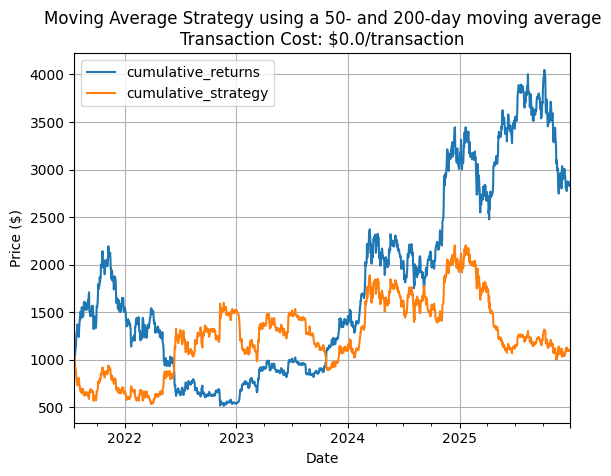

In [44]:
mabt.plot_strategy()

In [45]:
cret, cstrat = mabt.get_terminal_return()
print(f"Cumulative return: {cret*100:.2f}%\nCumulative return strategy: {cstrat*100:.2f}%")

Cumulative return: 187.00%
Cumulative return strategy: 9.00%


In [46]:
mabt.get_drawdown()

(np.float64(-0.7663456370856906), np.float64(-1.0717314222195864))

In [47]:
mabt_trans = MovingAverageBackTest('BTC-USD', 
                            '2021-01-01',
                            '2025-12-31',
                            trans_cost=0.36,
                            amount=init_investment)
cret_trans, cstrat_trans = mabt_trans.sma_strategy(sma1=50, sma2=200)
cret_trans, cstrat_trans

[*********************100%***********************]  1 of 1 completed


(np.float64(2869.45), np.float64(1085.34))

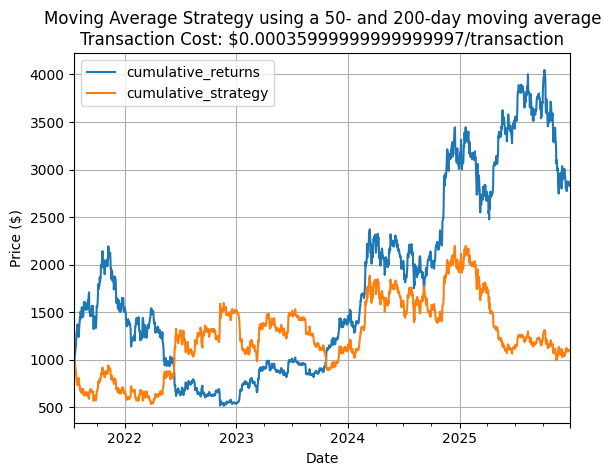

In [48]:
mabt_trans.plot_strategy()

In [49]:
cret_trans, cstrat_trans = mabt_trans.get_terminal_return()
print(f"Cumulative return: {cret_trans*100:.2f}%\nCumulative return strategy: {cstrat_trans*100:.2f}%")

Cumulative return: 187.00%
Cumulative return strategy: 9.00%


In [50]:
mabt_trans.get_drawdown()

(np.float64(-0.7663456370856906), np.float64(-1.0717314222195864))

In [51]:
mabt_hourly = MovingAverageBackTest('BTC-USD',
'2025-01-01',
'2025-12-31',
interval='4h',
trans_cost=0.0,
amount=init_investment)

cret, cstrat = mabt_hourly.sma_strategy(sma1=50, sma2=200)
cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(926.87), np.float64(1158.7))

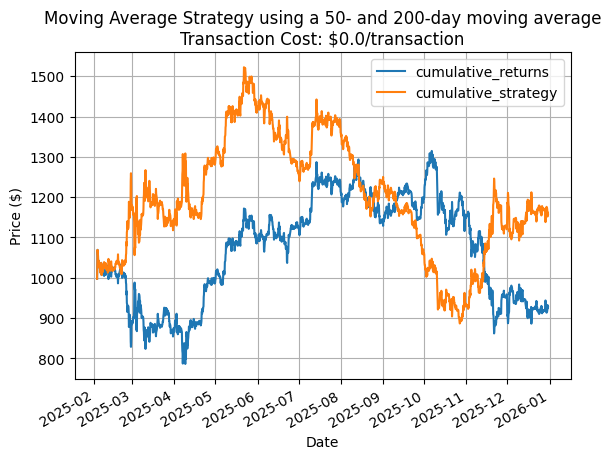

In [52]:
mabt_hourly.plot_strategy()

Strategy on the 4h chart beats the daily by double.

In [53]:
mabt_hourly.get_terminal_return(), mabt_hourly.get_volatility()

((-0.07, 0.16), (np.float64(0.13), np.float64(0.14)))

In [54]:
mabt_hourly = MovingAverageBackTest('BTC-USD',
'2025-01-01',
'2025-12-31',
interval='4h',
trans_cost=0.36,
amount=init_investment)

cret, cstrat = mabt_hourly.sma_strategy(sma1=50, sma2=200)
cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(926.87), np.float64(1152.46))

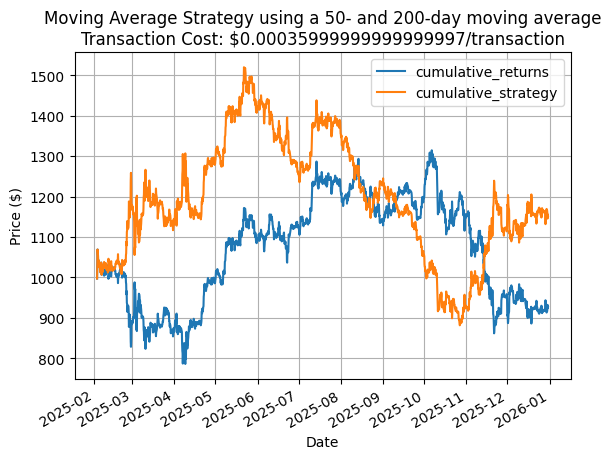

In [55]:
mabt_hourly.plot_strategy()

In [56]:
## ewm backtest

ewm_backtest = MovingAverageBackTest("BTC-USD",
                                     "2025-01-01",
                                     "2025-12-31",
                                     trans_cost=.36,
                                     amount=init_investment)
cret, cstrat = ewm_backtest.ewm_strategy(.1, .5)
cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(936.56), np.float64(160537.51))

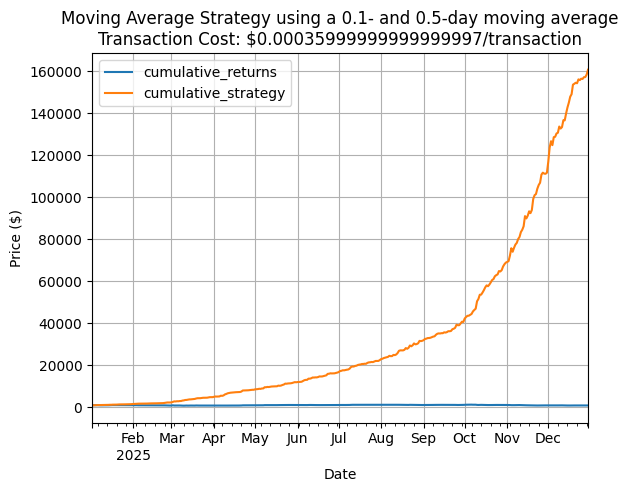

In [57]:
ewm_backtest.plot_strategy()

In [58]:
ewm_backtest.get_terminal_return(), ewm_backtest.get_volatility()

((-0.06, 159.54), (np.float64(0.12), np.float64(41.62)))